In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from astropy.io import fits
from astropy.table import Table

from scipy.optimize import minimize
from scipy.optimize import least_squares


In [33]:
campo = fits.open('./M41.fits')

In [34]:
campo.info()

Filename: ./M41.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       5   ()      
  1                1 BinTableHDU    138   2000R x 30C   [K, D, E, D, E, D, E, E, D, E, D, E, E, E, E, E, E, E, E, E, E, 8A, D, D, D, D, D, D, J, D]   


In [35]:
campo[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / 8-bit bytes                                    
NAXIS   =                    2 / 2-dimensional table                            
NAXIS1  =                  176 / width of table in bytes                        
NAXIS2  =                 2000 / number of rows in table                        
PCOUNT  =                    0 / heap size (no gap)                             
GCOUNT  =                    1 / one data group                                 
TFIELDS =                   30 / number of columns                              
TTYPE1  = 'source_id'          / label for column 1                             
TFORM1  = 'K       '           / format for column 1                            
TCOMM1  = 'Unique source identifier (unique within a particular Data Release)'  
TUCD1   = 'meta.id '           / VO Unified Content Descriptor for column 1     
TTYPE2  = 'ra      '        

In [36]:
Table = Table.read('./M41.fits', hdu=1)

In [37]:
Table

source_id,ra,ra_error,dec,dec_error,parallax,parallax_error,pm,pmra,pmra_error,pmdec,pmdec_error,ruwe,phot_g_mean_flux_over_error,phot_g_mean_mag,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_rp_mean_flux_over_error,phot_rp_mean_mag,bp_rp,radial_velocity,target_id,target_ra,target_dec,target_parallax,target_pm_ra,target_pm_dec,target_radial_velocity,epoch,target_separation (deg)
,deg,mas,deg,mas,mas,mas,mas / yr,mas / yr,mas / yr,mas / yr,mas / yr,,,mag,,mag,,mag,mag,km / s,,,,,,,,,
int64,float64,float32,float64,float32,float64,float32,float32,float64,float32,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,bytes8,float64,float64,float64,float64,float64,float64,int32,float64
2927009461931719040,101.51323389571529,0.015778234,-20.721845595774607,0.022649482,1.4061142086709058,0.029846596,4.642036,-4.452984511266016,0.01735016,-1.3112684443880251,0.025523229,1.2886716,4555.572,8.906782,4341.8706,8.878717,4172.92,8.925504,-0.04678631,20.554789,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.0032445786999685477
2927009393212237440,101.52748275851931,0.007549092,-20.72659785013504,0.010493631,1.3522227731139351,0.0140394885,4.8311863,-4.621183503441464,0.00843814,-1.4089083507767375,0.011948692,0.9208458,4102.8613,12.969056,2684.6445,13.207201,3327.0986,12.586679,0.62052155,22.64651,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.01580362398432804
2927009565010917888,101.52759919321238,0.013233067,-20.707665815620025,0.018555846,1.3488282476266924,0.024354033,3.219572,-3.134597232270959,0.014532883,-0.7348095516296687,0.02081857,1.1131909,5490.3,9.541347,3282.1494,9.533404,5111.4136,9.526099,0.0073051453,20.605297,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.01757733370175314
2927009633730421504,101.49075178237757,0.011837534,-20.720155663687137,0.016770551,1.4114457117752541,0.022405917,4.164051,-3.957287732952366,0.013212903,-1.2958373904354308,0.019198101,1.1981969,1415.858,14.568215,411.71524,15.029853,476.54794,13.941387,1.0884657,28.372093,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.020772319049854
2927008980887462400,101.51029689428272,0.012658242,-20.74008229813467,0.017906953,1.3637956603510422,0.023120163,4.6948833,-4.562790559846487,0.014109435,-1.105834540013178,0.020389577,1.1615713,5264.141,10.261493,4579.2056,10.266409,3637.203,10.227733,0.038676262,17.475235,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.021603713718560985
2927008740377202304,101.5378046735712,0.015039824,-20.72293782323805,0.02159661,1.4129887127253498,0.028483188,4.301125,-3.7899507360618414,0.016801052,-2.033703724116381,0.024419209,1.3591149,3804.576,10.054661,2850.7822,10.036918,2083.6587,10.065878,-0.028960228,13.893206,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.023691811840438292
2927008980895402368,101.50281832738021,0.010337764,-20.741685475644772,0.014351229,1.357741659986287,0.018498104,4.5320907,-4.272956066703009,0.011414934,-1.51052749390919,0.017169528,1.012165,1833.6575,14.4656105,422.65976,14.829661,595.2288,13.931498,0.8981638,24.365664,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.02492165347722718
2927008980895405056,101.49893735346963,0.010048102,-20.743019249117484,0.013891708,1.370459542475695,0.018460728,4.523692,-4.271527625428095,0.011389105,-1.4892415407078958,0.015838938,1.0189847,1723.6497,14.497212,394.60632,14.865079,595.4567,13.962225,0.90285397,21.565203,NGC 2287,101.51292,-20.71861,1.36,-4.339,-1.381,23.37,2000,0.027677143076336938


In [38]:
pmra = Table['pmra']
pmdec = Table['pmdec']
parallax = Table['parallax']

ra = Table['ra']
dec = Table['dec']

g_mag = Table['phot_g_mean_mag']
bp_rp = Table['bp_rp']

### VPD

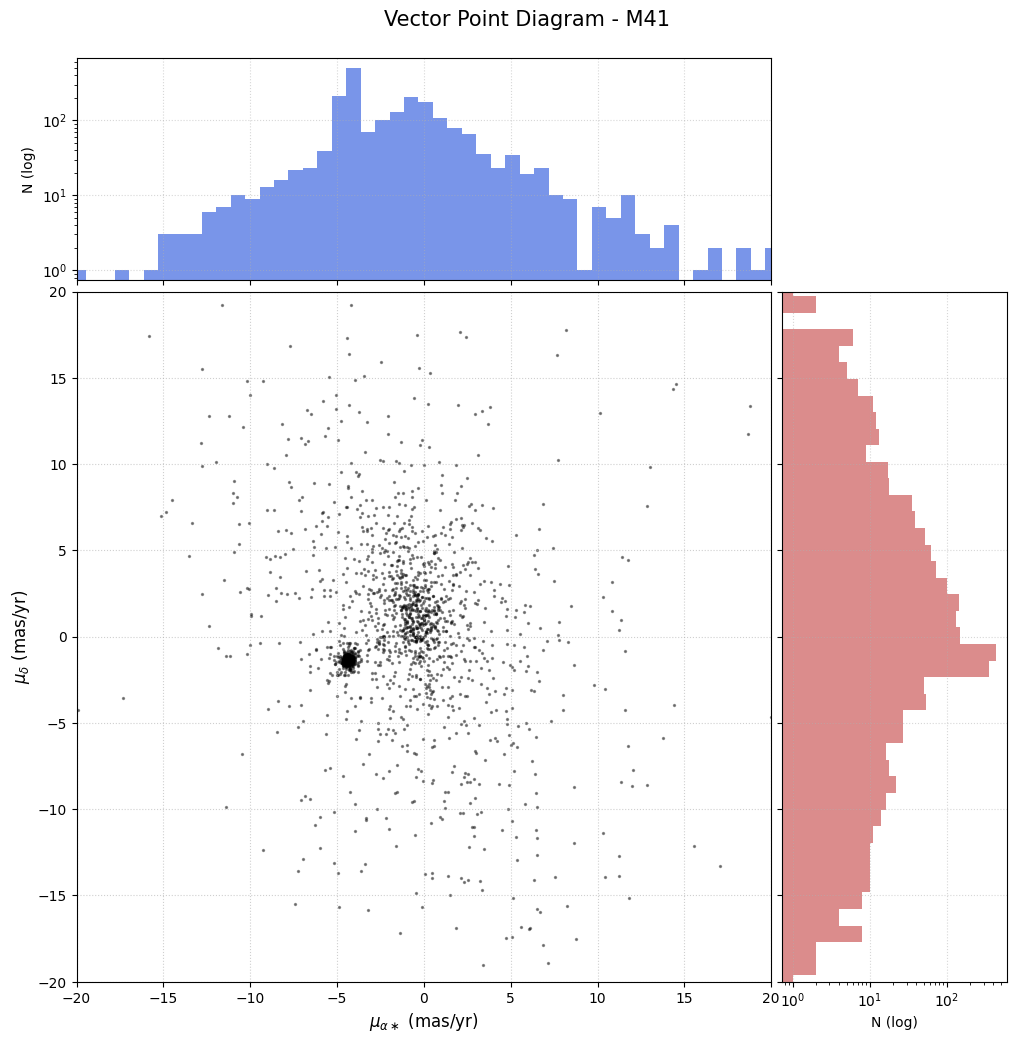

In [39]:
fig = plt.figure(figsize=(12, 12))

# Rejilla 4x4
gs = gridspec.GridSpec(4, 4, hspace=0.05, wspace=0.05)

ax_main   = fig.add_subplot(gs[1:4, 0:3])
ax_hist_x = fig.add_subplot(gs[0, 0:3], sharex=ax_main)
ax_hist_y = fig.add_subplot(gs[1:4, 3], sharey=ax_main)

ax_main.scatter(pmra, pmdec, s=2, c='black', alpha=0.4)
ax_main.set_xlabel(r'$\mu_{\alpha \ast}$ (mas/yr)', fontsize=12)
ax_main.set_ylabel(r'$\mu_{\delta}$ (mas/yr)', fontsize=12)
ax_main.grid(True, linestyle=':', alpha=0.6)

ax_main.set_xlim(-20, 20)
ax_main.set_ylim(-20, 20)

ax_hist_x.hist(pmra, bins=100, color='royalblue', alpha=0.7, log=True)

ax_hist_x.set_ylabel('N (log)')
ax_hist_x.tick_params(axis='x', labelbottom=False)  # oculta etiquetas x
ax_hist_x.grid(True, linestyle=':', alpha=0.5)

ax_hist_y.hist(pmdec, bins=100, color='indianred', alpha=0.7,
               orientation='horizontal', log=True)

ax_hist_y.set_xlabel('N (log)')
ax_hist_y.tick_params(axis='y', labelleft=False)  # oculta etiquetas y
ax_hist_y.grid(True, linestyle=':', alpha=0.5)

plt.suptitle('Vector Point Diagram - M41', y=0.92, fontsize=15)
plt.show()

In [40]:
bins = 100

hist_ra, edges_ra = np.histogram(pmra, bins=bins)
hist_dec, edges_dec = np.histogram(pmdec, bins=bins)

centers_ra = 0.5 * (edges_ra[1:] + edges_ra[:-1])
centers_dec = 0.5 * (edges_dec[1:] + edges_dec[:-1])

In [41]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

def residuals(params):

    mu1, sigma1, A1_ra, A2_ra, mu2, sigma2, A1_dec, A3_dec, mu3, sigma3 = params

    # Modelo RA
    model_ra = (
        gaussian(centers_ra, A1_ra, mu1, sigma1) +
        gaussian(centers_ra, A2_ra, mu2, sigma2)
    )

    # Modelo Dec
    model_dec = (
        gaussian(centers_dec, A1_dec, mu1, sigma1) +
        gaussian(centers_dec, A3_dec, mu3, sigma3)
    )

    res_ra = model_ra - hist_ra
    res_dec = model_dec - hist_dec

    return np.concatenate([res_ra, res_dec])


p0 = [
    -3, 1,          # mu1, sigma1 (cluster)
    100,          # A1_ra
    100, 0, 10,     # A2_ra, mu2, sigma2
    100,          # A1_dec
    100, 0, 8     # A3_dec, mu3, sigma3
]

In [42]:
result = least_squares(residuals, p0)
params_fit = result.x

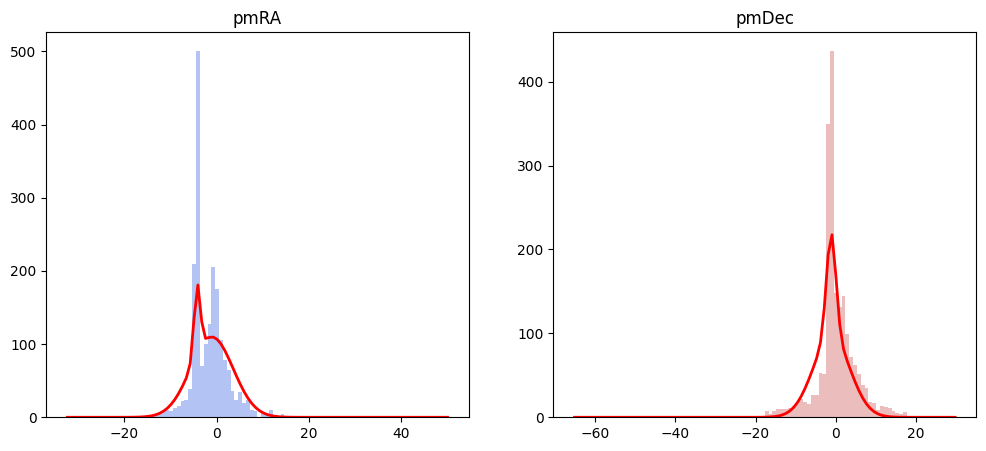

In [43]:
mu1, sigma1, A1_ra, A2_ra, mu2, sigma2, A1_dec, A3_dec, mu3, sigma3 = params_fit

model_ra = (
    gaussian(centers_ra, A1_ra, mu1, sigma1) +
    gaussian(centers_ra, A2_ra, mu2, sigma2)
)

model_dec = (
    gaussian(centers_dec, A1_dec, mu1, sigma1) +
    gaussian(centers_dec, A3_dec, mu3, sigma3)
)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.bar(centers_ra, hist_ra, width=np.diff(edges_ra)[0], alpha=0.4, color='royalblue')
plt.plot(centers_ra, model_ra, 'r-', lw=2)
plt.title("pmRA")

plt.subplot(1,2,2)
plt.bar(centers_dec, hist_dec, width=np.diff(edges_dec)[0], alpha=0.4, color='indianred')
plt.plot(centers_dec, model_dec, 'r-', lw=2)
plt.title("pmDec")

plt.show()

In [44]:
# Extraer parámetros ajustados
mu1, sigma1, A1_ra, A2_ra, mu2, sigma2, A1_dec, A3_dec, mu3, sigma3 = params_fit

print("\n===== Parámetros Ajustados =====\n")

print("Gaussiana 1 (Cluster - compartida RA y Dec)")
print(f"  μ1  = {mu1:.4f} mas/yr")
print(f"  σ1  = {sigma1:.4f} mas/yr\n")

print("Gaussiana 2 (Campo en pmRA)")
print(f"  μ2  = {mu2:.4f} mas/yr")
print(f"  σ2  = {sigma2:.4f} mas/yr\n")

print("Gaussiana 3 (Campo en pmDec)")
print(f"  μ3  = {mu3:.4f} mas/yr")
print(f"  σ3  = {sigma3:.4f} mas/yr\n")


===== Parámetros Ajustados =====

Gaussiana 1 (Cluster - compartida RA y Dec)
  μ1  = -1.0338 mas/yr
  σ1  = 4.6153 mas/yr

Gaussiana 2 (Campo en pmRA)
  μ2  = -4.2140 mas/yr
  σ2  = 0.6763 mas/yr

Gaussiana 3 (Campo en pmDec)
  μ3  = -1.0993 mas/yr
  σ3  = 1.1713 mas/yr



### Probabilidades de pertenencia

In [45]:
# Definición de las funciones de densidad (PDF)
def psi_cluster(mu_x, mu_y, mux_c, muy_c, sigma_c):
    """PDF circular para el cúmulo """
    return (1.0 / (2 * np.pi * sigma_c**2)) * np.exp(-0.5 * ((mu_x - mux_c)**2 + (mu_y - muy_c)**2) / sigma_c**2)

def psi_field(mu_x, mu_y, mux_f, muy_f, sigx_f, sigy_f, rho):
    """PDF elíptica para el campo """
    z = ((mu_x - mux_f)**2 / sigx_f**2 + 
         (mu_y - muy_f)**2 / sigy_f**2 - 
         2 * rho * (mu_x - mux_f) * (mu_y - muy_f) / (sigx_f * sigy_f))
    norm = 1.0 / (2 * np.pi * sigx_f * sigy_f * np.sqrt(1 - rho**2))
    return norm * np.exp(-0.5 * z / (1 - rho**2))

# Función de Verosimilitud (Log-Likelihood)
def neg_log_likelihood(params, mu_x, mu_y):
    """Calcula el logaritmo negativo de la verosimilitud total """
    mux_c, muy_c, sigma_c, mux_f, muy_f, sigx_f, sigy_f, rho, nf = params
    
    # Restricciones lógicas
    if sigma_c <= 0 or sigx_f <= 0 or sigy_f <= 0 or not (-1 < rho < 1) or not (0 <= nf <= 1):
        return 1e15
    
    pc = psi_cluster(mu_x, mu_y, mux_c, muy_c, sigma_c)
    pf = psi_field(mu_x, mu_y, mux_f, muy_f, sigx_f, sigy_f, rho)
    
    total_psi = (1 - nf) * pc + nf * pf
    # Evitar log(0)
    return -np.sum(np.log(total_psi + 1e-10))

def calculate_membership(pmra, pmdec):
    # Estimación inicial (Crucial para la convergencia)
    # Para M41: mux ~ -4.5, muy ~ -1.8 mas/yr
    initial_guess = [
        -4.3665, -1.3399 , 0.2633,     # Cluster: mux, muy, sigma
        -0.7410, -0.6275, 5.1546, 7.3140,  # Field: mux, muy, sigx, sigy
        0.0,                 # rho
        0.9                  # nf 
    ]

#def calculate_membership(pmra, pmdec):
#    # Estimación inicial (Crucial para la convergencia)
    # Para M41: mux ~ -4.5, muy ~ -1.8 mas/yr
#    initial_guess = [
#        -4.2520, -4.2520 , 2.5036,     # Cluster: mux, muy, sigma
#        -0.0476, -1.1686, 1.6593, 4.6558,  # Field: mux, muy, sigx, sigy
#        0.0,                 # rho
#        0.9                  # nf 
#    ]
    
    # Minimización usando SciPy
    res = minimize(neg_log_likelihood, initial_guess, args=(pmra, pmdec), method='L-BFGS-B',
                   bounds=[(None, None), (None, None), (0.01, None), 
                           (None, None), (None, None), (0.1, None), (0.1, None), 
                           (-0.99, 0.99), (0, 1)])
    
    if not res.success:
        print("Error en la optimización:", res.message)
        return None

    # Parámetros optimizados
    p = res.x
    #print("Parámetros finales:", p)

    # Cálculo de Probabilidades de Pertenencia (Regla de Bayes)
    # P = (Prob_Cúmulo) / (Prob_Total) [cite: 591, 594]
    pc_final = (1 - p[8]) * psi_cluster(pmra, pmdec, p[0], p[1], p[2])
    pf_final = p[8] * psi_field(pmra, pmdec, p[3], p[4], p[5], p[6], p[7])
    
    probabilities = pc_final / (pc_final + pf_final)
    
    return probabilities, p

In [46]:
probabilities, p = calculate_membership(pmra, pmdec)

names = [
    "µ_xc (Cluster RA)", "µ_yc (Cluster Dec)", "σ_c (Cluster Dispersion)",
    "µ_xf (Field RA)", "µ_yf (Field Dec)", "σx_f (Field RA Disp)",
    "σy_f (Field Dec Disp)", "ρ (Correlation)", "n_f (Field Fraction)"
]
print("-" * 45)
print(f"{'Parámetro':<25} | {'Valor':<15}")
print("-" * 45)
for name, value in zip(names, p):
    print(f"{name:<25} | {value:>15.4f}")
print("-" * 45)

---------------------------------------------
Parámetro                 | Valor          
---------------------------------------------
µ_xc (Cluster RA)         |         -4.3708
µ_yc (Cluster Dec)        |         -1.3646
σ_c (Cluster Dispersion)  |          0.1741
µ_xf (Field RA)           |         -0.6320
µ_yf (Field Dec)          |          0.5039
σx_f (Field RA Disp)      |          4.4886
σy_f (Field Dec Disp)     |          6.1503
ρ (Correlation)           |         -0.2780
n_f (Field Fraction)      |          0.7052
---------------------------------------------


---------------------------------------------
RESULTADO DEL FILTRADO (P > 0.5)
---------------------------------------------
Estrellas totales:      2000
Miembros encontrados:   590
Porcentaje de éxito:    29.50%
---------------------------------------------


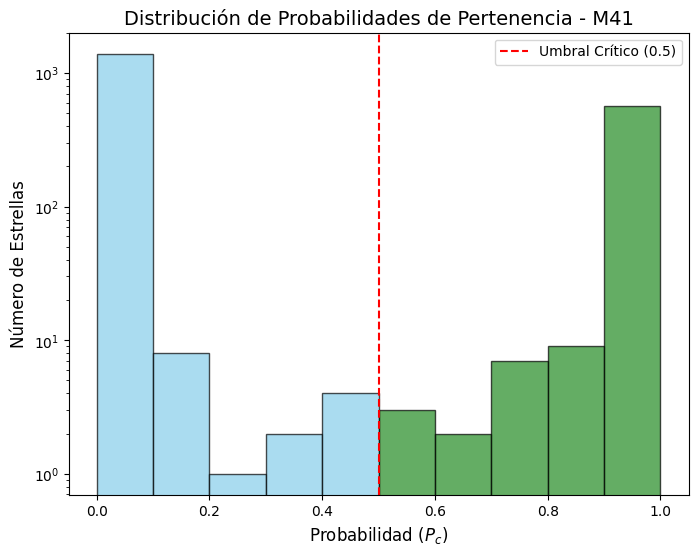

In [47]:
umbral = 0.5

# Conteo de miembros con P > umbral
n_members = np.sum(probabilities > umbral)
total_stars = len(probabilities)
percentage = (n_members / total_stars) * 100

print("-" * 45)
print(f"RESULTADO DEL FILTRADO (P > {umbral})")
print("-" * 45)
print(f"Estrellas totales:      {total_stars}")
print(f"Miembros encontrados:   {n_members}")
print(f"Porcentaje de éxito:    {percentage:.2f}%")
print("-" * 45)

# Histograma
plt.figure(figsize=(8, 6))

counts, bins, patches = plt.hist(probabilities, bins=10, range=(0, 1), color='skyblue', edgecolor='black', alpha=0.7)

# Resaltamos la zona de miembros en un color distinto
for i in range(len(patches)):
    if bins[i] >= umbral:
        patches[i].set_facecolor('forestgreen')

plt.axvline(umbral, color='red', linestyle='--', label=f'Umbral Crítico ({umbral})')

plt.title('Distribución de Probabilidades de Pertenencia - M41', fontsize=14)
plt.xlabel('Probabilidad ($P_c$)', fontsize=12)
plt.ylabel('Número de Estrellas', fontsize=12)
plt.yscale('log')  # Escala logarítmica para ver mejor el pico del cúmulo si es pequeño
plt.legend()

plt.show()

### Visualizacion del Cumulo

In [48]:
# Crear la máscara (Probabilidad > umbral)
mask = probabilities > umbral
mas_bot = probabilities < umbral

# Aplicar la máscara a todos los datos
m_ra, m_dec = ra[mask], dec[mask]
m_pmra, m_pmdec = pmra[mask], pmdec[mask]
m_g, m_bprp = g_mag[mask], bp_rp[mask]

m_g_bot, m_bprp_bot = g_mag[mas_bot], bp_rp[mas_bot]

print(f"Estrellas identificadas como miembros probables: {len(m_ra)}")

Estrellas identificadas como miembros probables: 590


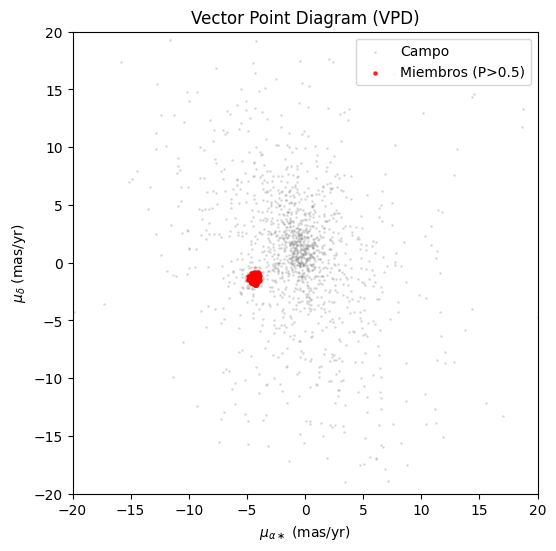

In [49]:
plt.figure(figsize=(6,6))

plt.scatter(pmra, pmdec, c='gray', s=1, alpha=0.2, label='Campo')
plt.scatter(m_pmra, m_pmdec, c='red', s=5, alpha=0.8, label=f'Miembros (P>{umbral})')

plt.xlabel(r'$\mu_{\alpha \ast}$ (mas/yr)')
plt.ylabel(r'$\mu_{\delta}$ (mas/yr)')
plt.title('Vector Point Diagram (VPD)')
plt.legend()

plt.xlim(-20, 20)  
plt.ylim(-20, 20)

plt.show()

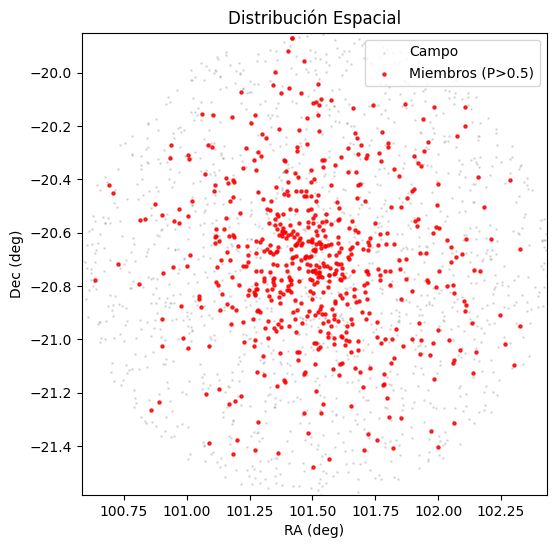

In [50]:
plt.figure(figsize=(6,6))

plt.scatter(ra, dec, c='gray', s=1, alpha=0.2, label='Campo')
plt.scatter(m_ra, m_dec, c='red', s=5, alpha=0.8, label=f'Miembros (P>{umbral})')

plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.title('Distribución Espacial')
plt.legend()

plt.xlim(min(ra), max(ra)) 
plt.ylim(min(dec), max(dec))

plt.show()

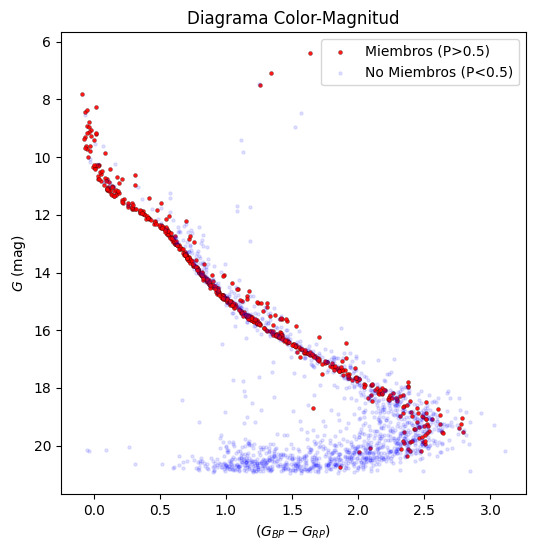

In [51]:
plt.figure(figsize=(6,6))

#plt.scatter(bp_rp, g_mag, c='gray', s=1, alpha=0.2, label='Campo')
plt.scatter(m_bprp, m_g, c='red', s=8, alpha=0.9, edgecolors='black', linewidths=0.2, label=f'Miembros (P>{umbral})')
plt.scatter(m_bprp_bot, m_g_bot, c='blue', s=5, alpha=0.1, label=f'No Miembros (P<{umbral})')

plt.xlabel('$(G_{BP} - G_{RP})$')
plt.ylabel('$G$ (mag)')
plt.gca().invert_yaxis()
plt.title('Diagrama Color-Magnitud')
plt.legend()    

plt.show()

### HDBSCAN

In [52]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
#from sklearn.preprocessing import StandardScaler
import numpy as np

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from sklearn.cluster import HDBSCAN
import astropy.units as u
# from zero_point import zpt
#from tqdm import tqdm
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_samples, silhouette_score


In [53]:
data = np.column_stack((pmra, pmdec, parallax))
#data = np.column_stack((ra, dec,pmra, pmdec, parallax))
#data = np.column_stack((pmra, pmdec, parallax))
data = RobustScaler().fit_transform(data)

In [54]:
hd = HDBSCAN(min_cluster_size=100, min_samples=6, metric='euclidean').fit(data)
#hd = HDBSCAN(min_cluster_size=10, metric='euclidean').fit(data)

In [55]:
labels = hd.labels_
resumen = pd.Series(labels).value_counts().sort_index()
print(resumen)

-1    1031
 0     639
 1     330
Name: count, dtype: int64


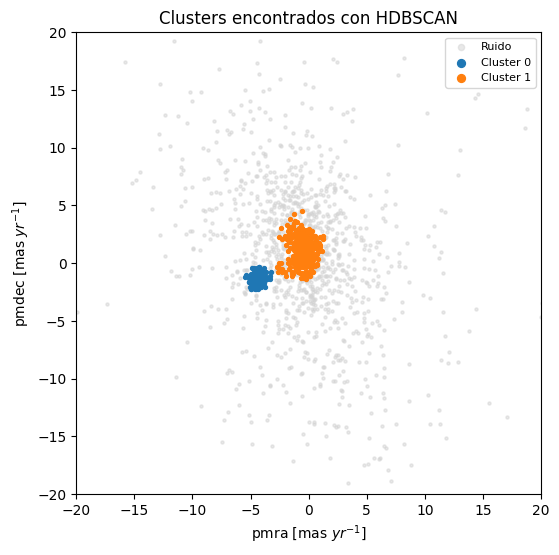

In [56]:
noise = labels == -1
clusters = labels != -1
unique_clusters = np.unique(labels[clusters])


plt.figure(figsize=(6,6))
plt.scatter(pmra[noise], pmdec[noise], s=5, c='lightgray', label='Ruido', alpha=0.5)

for c in unique_clusters:
    mask = labels == c
    plt.scatter(pmra[mask], pmdec[mask], s=8, label=f'Cluster {c}')

plt.xlabel('pmra [mas $yr^{-1}$]')
plt.ylabel('pmdec [mas $yr^{-1}$]')
plt.title('Clusters encontrados con HDBSCAN')
plt.legend(markerscale=2, fontsize=8)
plt.xlim(-20, 20)  
plt.ylim(-20, 20)
plt.show()

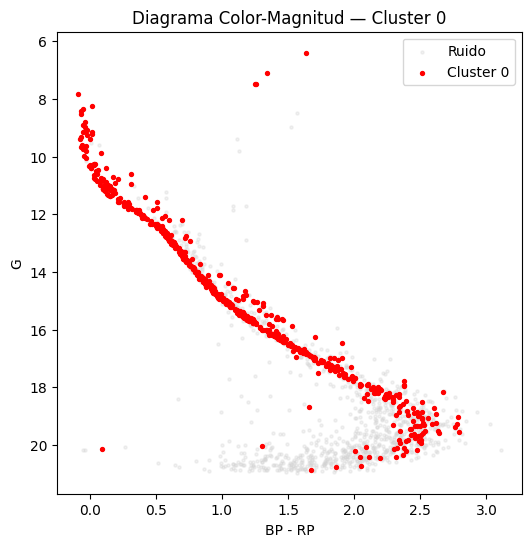

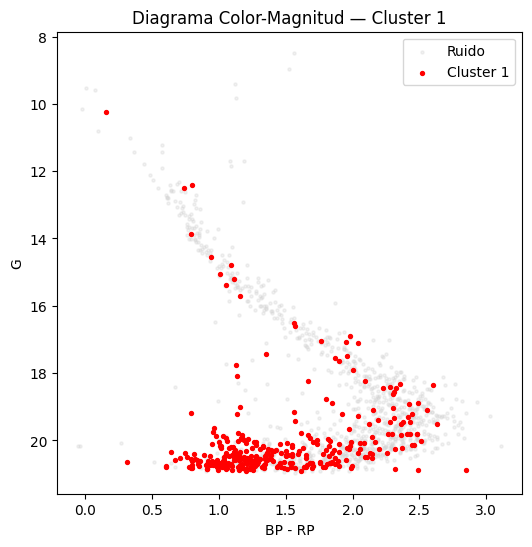

In [57]:
noise_mask = labels == -1
cluster_labels = np.unique(labels)
cluster_labels = cluster_labels[cluster_labels != -1]

for c in cluster_labels:
    cluster_mask = labels == c

    plt.figure(figsize=(6,6))
    plt.scatter(bp_rp[noise_mask], g_mag[noise_mask], s=5, color='lightgray', alpha=0.3, label='Ruido')
    plt.scatter(bp_rp[cluster_mask], g_mag[cluster_mask], s=8, color='red', label=f'Cluster {c}')
    plt.xlabel('BP - RP')
    plt.ylabel('G')
    plt.title(f'Diagrama Color-Magnitud — Cluster {c}')
    plt.gca().invert_yaxis()

    plt.legend()
    plt.show()

Silhouette score global: 0.4595


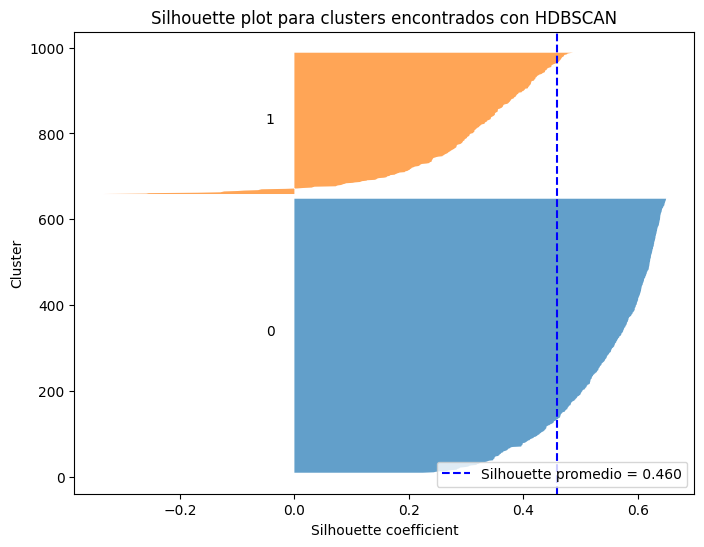

In [58]:
# Quitar ruido (-1)
mask = labels != -1
X = data[mask]
labels_clean = labels[mask]

# Calcular siluetas
silhouette_vals = silhouette_samples(X, labels_clean)
silhouette_avg = silhouette_score(X, labels_clean)

print(f"Silhouette score global: {silhouette_avg:.4f}")

clusters = np.unique(labels_clean)

fig, ax = plt.subplots(figsize=(8,6))

y_lower = 10

for cluster in clusters:

    sil_cluster = silhouette_vals[labels_clean == cluster]
    sil_cluster.sort()

    size_cluster = sil_cluster.shape[0]
    y_upper = y_lower + size_cluster

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        sil_cluster,
        alpha=0.7
    )

    ax.text(-0.05, y_lower + 0.5 * size_cluster, str(cluster))

    y_lower = y_upper + 10

# línea vertical del valor promedio
ax.axvline(x=silhouette_avg, linestyle="--", color="blue",
           label=f"Silhouette promedio = {silhouette_avg:.3f}")

ax.set_xlabel("Silhouette coefficient")
ax.set_ylabel("Cluster")
ax.set_title("Silhouette plot para clusters encontrados con HDBSCAN")

ax.legend()

plt.show()

In [59]:
df_sil = pd.DataFrame({
    "cluster": labels_clean,
    "silhouette": silhouette_vals
})

# Promedio por cluster
sil_cluster_mean = df_sil.groupby("cluster")["silhouette"].mean()

print(sil_cluster_mean)

cluster
0    0.539723
1    0.304250
Name: silhouette, dtype: float64


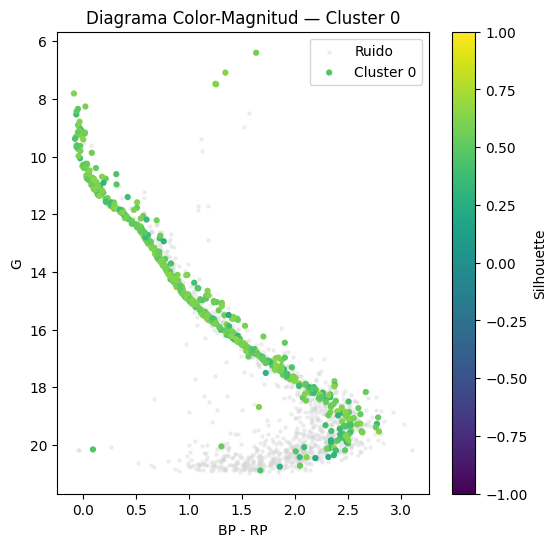

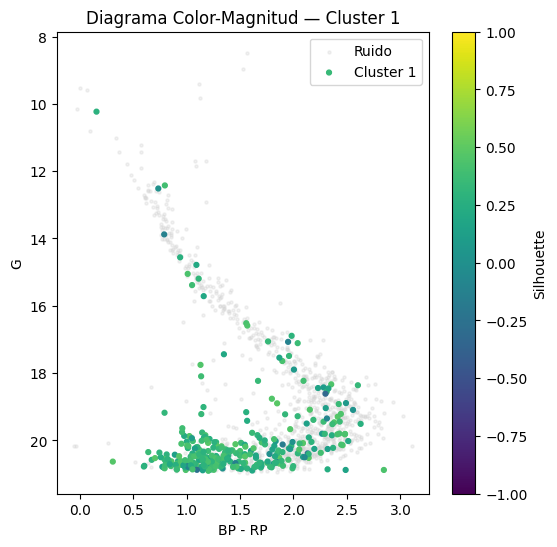

In [60]:
# máscaras
noise_mask = labels == -1
cluster_mask = labels != -1

# calcular siluetas solo para estrellas en clusters
silhouette_vals = silhouette_samples(data[cluster_mask], labels[cluster_mask])

# guardar siluetas en un array del tamaño original
sil_full = np.full(len(labels), np.nan)
sil_full[cluster_mask] = silhouette_vals

# clusters encontrados
cluster_labels = np.unique(labels)
cluster_labels = cluster_labels[cluster_labels != -1]

for c in cluster_labels:

    mask_c = labels == c

    plt.figure(figsize=(6,6))

    # ruido
    plt.scatter(
        bp_rp[noise_mask],
        g_mag[noise_mask],
        s=5,
        color='lightgray',
        alpha=0.3,
        label='Ruido'
    )

    # cluster coloreado por silueta
    sc = plt.scatter(
        bp_rp[mask_c],
        g_mag[mask_c],
        c=sil_full[mask_c],
        cmap='viridis',
        vmin=-1,
        vmax=1,
        s=12,
        label=f'Cluster {c}'
    )

    plt.xlabel('BP - RP')
    plt.ylabel('G')
    plt.title(f'Diagrama Color-Magnitud — Cluster {c}')
    plt.gca().invert_yaxis()

    cbar = plt.colorbar(sc)
    cbar.set_label('Silhouette')

    plt.legend()
    plt.show()